# SCIONA Build Status — Extended Evaluation

Systematic multi-repo analysis of `sciona status --json` outputs.

**Repositories**: `airbyte`, `axios`, `commons-lang`, `fastapi`, `guava`, `nest`, `pydantic`, `sympy`, `vscode`, `webpack`

**Sections**:
1. Definitions
2. Loading & normalisation
3. Repository overview (totals)
4. Per-language breakdown
5. Scope breakdown (non-tests vs tests)
6. Callsite funnel analysis
7. Callsite pair expansion
8. Graph metrics (nodes / edges / density)
9. Pre-persist filter buckets
10. Build performance (wall time + phase breakdown)
11. Cross-metric correlation
12. Anomaly / flag summary

Hardware used for these runs: `MacBook Pro 2019, Intel Core i9 2.4 GHz`

---
## 1  Definitions

### Structural quantities
| Field | Meaning |
|---|---|
| `files` | Source files included in the committed snapshot for enabled languages |
| `nodes` | Structural nodes persisted in CoreDB for the committed snapshot |
| `edges` | Structural CoreDB edges persisted for the committed snapshot |
| `nodes_per_file` | Mean callable-node density per source file |
| `edge_to_node_ratio` | Structural edge count ÷ node count — graph connectivity proxy |

### Callsite funnel quantities
| Field | Meaning |
|---|---|
| `observed_syntactic_callsites` | Syntactic call observations emitted before pre-persist filtering |
| `filtered_pre_persist` | Callsites excluded before persisted-callsite retention |
| `persisted_callsites` | Retained callsite observations after pre-persist filtering |
| `persisted_accepted` | Retained callsites whose strict resolution outcome is *accepted* |
| `persisted_dropped` | Retained callsites whose strict resolution outcome is *dropped* |
| `callsite_pairs` / `finalized_call_edges` | Deduplicated pairs / graph edges derived from accepted callsites |

### Pre-persist filter buckets
| Field | Meaning |
|---|---|
| `no_in_repo_candidate_terminal` | No in-repo candidate materialised for a terminal callee |
| `no_in_repo_candidate_qualified` | No in-repo candidate materialised for a qualified callee |
| `accepted_outside_in_repo` | Callee accepted but outside the repo boundary |
| `invalid_observation_shape` | Malformed observation dropped before resolution |

### Derived / computed metrics used in this notebook
| Metric | Formula |
|---|---|
| `filter_rate` | `filtered_pre_persist / observed_syntactic_callsites` |
| `drop_rate` | `persisted_dropped / persisted_callsites` |
| `funnel_yield` | `persisted_accepted / observed_syntactic_callsites` — end-to-end callsite acceptance |
| `edge_resolution_rate` | `finalized_call_edges / callsite_pairs` |
| `test_callsite_share` | `tests_callsite_pairs / total_callsite_pairs` |
| `nodes_per_file` | From `structural_density` block |
| `callsites_per_file` | `callsite_pairs / files` |
| `edge_to_node_ratio` | `edges / nodes` |

---
## 2  Loading & normalisation

In [165]:
import json
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

warnings.filterwarnings("ignore")
pd.set_option("display.float_format", "{:.4f}".format)
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 160)

In [166]:
# ── Colour palette (Okabe–Ito, colour-blind safe) ─────────────────────────────
PALETTE = [
    "#0072B2",  # blue
    "#E69F00",  # orange
    "#009E73",  # bluish green
    "#CC79A7",  # purple
    "#56B4E9",  # sky blue
    "#D55E00",  # vermillion
    "#F0E442",  # yellow
    "#000000",  # black
    "#999999",  # grey
    "#332288",  # indigo
]

LANG_COLORS = {
    "python":     "#0072B2",
    "typescript": "#E69F00",
    "javascript": "#009E73",
    "java":       "#D55E00",
    "other":      "#999999",
}

In [167]:
REPORTS_DIR = Path("reports")
REPORT_FILES = sorted(REPORTS_DIR.glob("*.json"))

reports: dict[str, dict] = {}
for path in REPORT_FILES:
    with open(path) as f:
        reports[path.stem] = json.load(f)

REPOS = sorted(reports.keys())
print(f"Loaded {len(REPOS)} reports: {REPOS}")

Loaded 10 reports: ['airbyte', 'axios', 'commons-lang', 'fastapi', 'guava', 'nest', 'pydantic', 'sympy', 'vscode', 'webpack']


In [168]:
# ── Repo-level flat frame (totals) ────────────────────────────────────────────
repo_rows = []
for repo, r in reports.items():
    s = r["summary"]
    t = s["totals"]
    sd = t["structural_density"]
    csf = t["call_site_funnel"]
    pcp = t["persisted_callsite_pair_expansion"]
    by_scope_cs = t["callsite_pairs_by_scope"]
    by_scope_fe = t["finalized_call_edges_by_scope"]
    fpp = t["filtered_pre_persist_buckets"]

    repo_rows.append({
        "repo": repo,
        # structural
        "files":                     t["files"],
        "nodes":                     t["nodes"],
        "edges":                     t["edges"],
        "nodes_per_file":            sd["nodes_per_file"],
        "callsites_per_file":        sd["eligible_callsites_per_file"],
        "low_node_file_ratio":       sd["low_node_file_ratio"],
        # funnel
        "observed_callsites":        csf["observed_syntactic_callsites"],
        "filtered_pre_persist":      csf["filtered_pre_persist"],
        "persisted_callsites":       csf["persisted_callsites"],
        "persisted_accepted":        csf["persisted_accepted"],
        "persisted_dropped":         csf["persisted_dropped"],
        # callsite pairs / edges
        "callsite_pairs":            t["callsite_pairs"]["count"],
        "finalized_call_edges":      t["finalized_call_edges"]["count"],
        # scope split
        "cs_non_tests":              by_scope_cs["non_tests"]["count"],
        "cs_tests":                  by_scope_cs["tests"]["count"],
        "fe_non_tests":              by_scope_fe["non_tests"]["count"],
        "fe_tests":                  by_scope_fe["tests"]["count"],
        # pair expansion
        "pair_expansion_factor":     pcp["pair_expansion_factor"],
        "multi_pair_share":          pcp["multi_pair_share"],
        "max_pairs_single_callsite": pcp["max_pairs_for_single_persisted_callsite"],
        # filter buckets
        "fpp_no_repo_terminal":      fpp["no_in_repo_candidate_terminal"],
        "fpp_no_repo_qualified":     fpp["no_in_repo_candidate_qualified"],
        "fpp_accepted_outside":      fpp["accepted_outside_in_repo"],
        "fpp_invalid_shape":         fpp["invalid_observation_shape"],
        # build timing
        "build_wall_seconds":        s["build_wall_seconds"],
        "build_total_seconds":       s["build_total_seconds"],
    })

repo_df = pd.DataFrame(repo_rows).set_index("repo")

# ── Derived metrics ───────────────────────────────────────────────────────────
repo_df["filter_rate"]          = repo_df["filtered_pre_persist"]  / repo_df["observed_callsites"]
repo_df["drop_rate"]            = repo_df["persisted_dropped"]     / repo_df["persisted_callsites"].replace(0, np.nan)
repo_df["funnel_yield"]         = repo_df["persisted_accepted"]    / repo_df["observed_callsites"]
repo_df["edge_resolution_rate"] = repo_df["finalized_call_edges"]  / repo_df["callsite_pairs"].replace(0, np.nan)
repo_df["test_callsite_share"]  = repo_df["cs_tests"]              / repo_df["callsite_pairs"].replace(0, np.nan)
repo_df["edge_to_node_ratio"]   = repo_df["edges"]                 / repo_df["nodes"].replace(0, np.nan)
repo_df["fpp_total"]            = (
    repo_df[["fpp_no_repo_terminal", "fpp_no_repo_qualified",
              "fpp_accepted_outside",  "fpp_invalid_shape"]].sum(axis=1)
)
repo_df["fpp_total_rate"]       = repo_df["fpp_total"] / repo_df["observed_callsites"].replace(0, np.nan)

print(f"repo_df shape: {repo_df.shape}")
repo_df.head(3)

repo_df shape: (10, 34)


,files,nodes,edges,nodes_per_file,callsites_per_file,low_node_file_ratio,observed_callsites,filtered_pre_persist,persisted_callsites,persisted_accepted,persisted_dropped,callsite_pairs,finalized_call_edges,cs_non_tests,cs_tests,fe_non_tests,fe_tests,pair_expansion_factor,multi_pair_share,max_pairs_single_callsite,fpp_no_repo_terminal,fpp_no_repo_qualified,fpp_accepted_outside,fpp_invalid_shape,build_wall_seconds,build_total_seconds,filter_rate,drop_rate,funnel_yield,edge_resolution_rate,test_callsite_share,edge_to_node_ratio,fpp_total,fpp_total_rate
repo,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
airbyte,3288,25275,24450,7.6870,4.3957,0.2232,15626,896,14730,14441,289,14453,13613,13848,605,13008,605,0.9812,0.0004,2,0,896,0,0,63.1584,59.8941,0.0573,0.0196,0.9242,0.9419,0.0419,0.9674,896,0.0573
axios,173,576,642,3.3295,0.9538,0.5491,231,66,165,161,4,165,163,158,7,156,7,1.0000,0.0121,2,0,66,0,0,3.1120,2.5183,0.2857,0.0242,0.6970,0.9879,0.0424,1.1146,66,0.2857
commons-lang,534,11566,11603,21.6592,10.7079,0.0487,5692,205,5487,5376,111,5718,5713,3667,2051,3662,2051,1.0421,0.0126,10,0,205,0,0,18.7037,17.8362,0.0360,0.0202,0.9445,0.9991,0.3587,1.0032,205,0.0360


In [169]:
# ── Per-language flat frame ────────────────────────────────────────────────────
lang_rows = []
for repo, r in reports.items():
    for lang in r["summary"]["languages"]:
        sd  = lang["structural_density"]
        csf = lang["call_site_funnel"]
        pcp = lang["persisted_callsite_pair_expansion"]
        bcs = lang["callsite_pairs_by_scope"]
        bfe = lang["finalized_call_edges_by_scope"]
        fpp = lang.get("filtered_pre_persist_buckets", {})

        lang_rows.append({
            "repo": repo,
            "language":                  lang["language"],
            "files":                     lang["files"],
            "nodes":                     lang["nodes"],
            "edges":                     lang["edges"],
            "nodes_per_file":            sd["nodes_per_file"],
            "callsites_per_file":        sd["eligible_callsites_per_file"],
            "low_node_file_ratio":       sd["low_node_file_ratio"],
            "observed_callsites":        csf["observed_syntactic_callsites"],
            "filtered_pre_persist":      csf["filtered_pre_persist"],
            "persisted_callsites":       csf["persisted_callsites"],
            "persisted_accepted":        csf["persisted_accepted"],
            "persisted_dropped":         csf["persisted_dropped"],
            "callsite_pairs":            lang["callsite_pairs"]["count"],
            "finalized_call_edges":      lang["finalized_call_edges"]["count"],
            "cs_non_tests":              bcs["non_tests"]["count"],
            "cs_tests":                  bcs["tests"]["count"],
            "fe_non_tests":              bfe["non_tests"]["count"],
            "fe_tests":                  bfe["tests"]["count"],
            "pair_expansion_factor":     pcp["pair_expansion_factor"],
            "multi_pair_share":          pcp["multi_pair_share"],
            "max_pairs_single_callsite": pcp["max_pairs_for_single_persisted_callsite"],
            "fpp_no_repo_terminal":      fpp.get("no_in_repo_candidate_terminal", 0),
            "fpp_no_repo_qualified":     fpp.get("no_in_repo_candidate_qualified", 0),
            "fpp_accepted_outside":      fpp.get("accepted_outside_in_repo", 0),
            "fpp_invalid_shape":         fpp.get("invalid_observation_shape", 0),
        })

lang_df = pd.DataFrame(lang_rows)

lang_df["filter_rate"]          = lang_df["filtered_pre_persist"] / lang_df["observed_callsites"]
lang_df["drop_rate"]            = lang_df["persisted_dropped"]     / lang_df["persisted_callsites"].replace(0, np.nan)
lang_df["funnel_yield"]         = lang_df["persisted_accepted"]    / lang_df["observed_callsites"]
lang_df["edge_resolution_rate"] = lang_df["finalized_call_edges"]  / lang_df["callsite_pairs"].replace(0, np.nan)
lang_df["test_callsite_share"]  = lang_df["cs_tests"]              / lang_df["callsite_pairs"].replace(0, np.nan)
lang_df["edge_to_node_ratio"]   = lang_df["edges"]                 / lang_df["nodes"].replace(0, np.nan)

print(f"lang_df shape: {lang_df.shape}")
lang_df.head()

lang_df shape: (22, 32)


,repo,language,files,nodes,edges,nodes_per_file,callsites_per_file,low_node_file_ratio,observed_callsites,filtered_pre_persist,persisted_callsites,persisted_accepted,persisted_dropped,callsite_pairs,finalized_call_edges,cs_non_tests,cs_tests,fe_non_tests,fe_tests,pair_expansion_factor,multi_pair_share,max_pairs_single_callsite,fpp_no_repo_terminal,fpp_no_repo_qualified,fpp_accepted_outside,fpp_invalid_shape,filter_rate,drop_rate,funnel_yield,edge_resolution_rate,test_callsite_share,edge_to_node_ratio
0,airbyte,java,473,4144,3829,8.7611,3.3150,0.0000,1623,54,1569,1556,13,1568,1568,1108,460,1108,460,0.9994,0.0038,2,0,54,0,0,0.0333,0.0083,0.9587,1.0000,0.2934,0.9240
1,airbyte,javascript,44,147,127,3.3409,1.2045,0.2045,53,0,53,53,0,53,53,53,0,53,0,1.0000,0.0000,1,0,0,0,0,0.0000,0.0000,1.0000,1.0000,0.0000,0.8639
2,airbyte,python,2768,20976,20488,7.5780,4.6351,0.2616,13948,842,13106,12830,276,12830,11990,12685,145,11845,145,0.9789,0.0000,1,0,842,0,0,0.0604,0.0211,0.9198,0.9345,0.0113,0.9767
3,airbyte,typescript,3,8,6,2.6667,0.6667,0.3333,2,0,2,2,0,2,2,2,0,2,0,1.0000,0.0000,1,0,0,0,0,0.0000,0.0000,1.0000,1.0000,0.0000,0.7500
4,axios,javascript,167,438,510,2.6228,0.9880,0.5509,231,66,165,161,4,165,163,158,7,156,7,1.0000,0.0121,2,0,66,0,0,0.2857,0.0242,0.6970,0.9879,0.0424,1.1644


In [170]:
# ── Per-language-per-scope flat frame ─────────────────────────────────────────
#
# Two schema variants exist across the 10 repos:
#
# Variant A — scope breakdown present:
#   lang['call_site_funnel_by_scope']  = {'non_tests': {...}, 'tests': {...}}
#   When a scope has zero persisted callsites, the PCP block emits:
#     pair_expansion_factor: null, multi_pair_share: null
#   These are structural nulls (empty-scope) → NaN, flagged by empty_scope=True.
#
# Variant B — no scope breakdown at all:
#   lang['call_site_funnel_by_scope']  = null   (the dict itself is None)
#   Observed in languages from repos where scope separation is unavailable.
#   We emit one row per scope with all scope-level fields NaN,
#   flagged by no_scope_breakdown=True.
#
# Both flags are first-class columns so downstream aggregations can filter
# or annotate them deliberately rather than silently skipping NaN.

def _pcp_field(pcp: dict, key: str, empty_scope: bool):
    """Return pcp[key], converting null-on-empty-scope to NaN.
    Raises if None appears on a non-empty scope (unexpected schema gap).
    """
    val = pcp[key]
    if val is None:
        if not empty_scope:
            raise ValueError(
                f"pcp['{key}'] is None on a non-empty scope — unexpected schema gap"
            )
        return np.nan
    return val


# Canonical NaN row for Variant B — all scope-level count/rate fields absent.
_NAN_SCOPE_COUNTS = dict(
    callsite_pairs=np.nan, finalized_call_edges=np.nan,
    observed_callsites=np.nan, filtered_pre_persist=np.nan,
    persisted_callsites=np.nan, persisted_accepted=np.nan, persisted_dropped=np.nan,
    pair_expansion_factor=np.nan, multi_pair_share=np.nan, max_pairs_single_callsite=np.nan,
    fpp_no_repo_terminal=np.nan, fpp_no_repo_qualified=np.nan,
    fpp_accepted_outside=np.nan, fpp_invalid_shape=np.nan,
)


scope_rows = []
for repo, r in reports.items():
    for lang in r["summary"]["languages"]:
        csf_map = lang["call_site_funnel_by_scope"]          # None in Variant B
        pcp_map = lang["persisted_callsite_pair_expansion_by_scope"]  # None in Variant B
        cs_map  = lang["callsite_pairs_by_scope"]             # None in Variant B
        fe_map  = lang["finalized_call_edges_by_scope"]       # None in Variant B
        fpp_map = lang.get("filtered_pre_persist_buckets_by_scope")   # None or absent

        # ── Variant B: entire scope breakdown is null ──────────────────────────
        if csf_map is None:
            for scope in ("non_tests", "tests"):
                scope_rows.append({
                    "repo": repo, "language": lang["language"], "scope": scope,
                    "empty_scope":        False,   # unknown, not the same as empty
                    "no_scope_breakdown": True,
                    **_NAN_SCOPE_COUNTS,
                })
            continue

        # ── Variant A: scope breakdown present ────────────────────────────────
        for scope in ("non_tests", "tests"):
            csf = csf_map[scope]
            pcp = pcp_map[scope]
            fpp = (fpp_map or {}).get(scope, {})

            # empty_scope: persisted_callsites == 0 drives the null in the PCP block.
            empty = (pcp["persisted_callsites"] == 0)

            scope_rows.append({
                "repo":                      repo,
                "language":                  lang["language"],
                "scope":                     scope,
                "empty_scope":               empty,
                "no_scope_breakdown":        False,
                # ── counts ────────────────────────────────────────────────────
                "callsite_pairs":            cs_map[scope]["count"],
                "finalized_call_edges":      fe_map[scope]["count"],
                "observed_callsites":        csf["observed_syntactic_callsites"],
                "filtered_pre_persist":      csf["filtered_pre_persist"],
                "persisted_callsites":       csf["persisted_callsites"],
                "persisted_accepted":        csf["persisted_accepted"],
                "persisted_dropped":         csf["persisted_dropped"],
                # ── pair expansion (nullable on empty scope) ──────────────────
                "pair_expansion_factor":     _pcp_field(pcp, "pair_expansion_factor", empty),
                "multi_pair_share":          _pcp_field(pcp, "multi_pair_share",       empty),
                "max_pairs_single_callsite": pcp["max_pairs_for_single_persisted_callsite"],
                # ── filter buckets ────────────────────────────────────────────
                "fpp_no_repo_terminal":      fpp.get("no_in_repo_candidate_terminal", 0),
                "fpp_no_repo_qualified":     fpp.get("no_in_repo_candidate_qualified", 0),
                "fpp_accepted_outside":      fpp.get("accepted_outside_in_repo",       0),
                "fpp_invalid_shape":         fpp.get("invalid_observation_shape",      0),
            })

scope_df = pd.DataFrame(scope_rows)

# Rate columns on Variant A rows only; Variant B rows remain NaN throughout.
# replace(0, nan) handles empty-scope zeros; no_scope_breakdown rows already NaN.
_obs  = scope_df["observed_callsites"].replace(0, np.nan)
_pers = scope_df["persisted_callsites"].replace(0, np.nan)
scope_df["filter_rate"]  = scope_df["filtered_pre_persist"] / _obs
scope_df["drop_rate"]    = scope_df["persisted_dropped"]     / _pers
scope_df["funnel_yield"] = scope_df["persisted_accepted"]    / _obs

n_empty   = scope_df["empty_scope"].sum()
n_no_breakdown = scope_df["no_scope_breakdown"].sum()
print(f"scope_df shape: {scope_df.shape}")
print(f"  empty_scope rows (NaN by design — zero callsites in scope):  {n_empty}")
print(f"  no_scope_breakdown rows (NaN by design — breakdown absent):  {n_no_breakdown}")
print()
scope_df.head(8)

scope_df shape: (44, 22)
  empty_scope rows (NaN by design — zero callsites in scope):  5
  no_scope_breakdown rows (NaN by design — breakdown absent):  8



,repo,language,scope,empty_scope,no_scope_breakdown,callsite_pairs,finalized_call_edges,observed_callsites,filtered_pre_persist,persisted_callsites,persisted_accepted,persisted_dropped,pair_expansion_factor,multi_pair_share,max_pairs_single_callsite,fpp_no_repo_terminal,fpp_no_repo_qualified,fpp_accepted_outside,fpp_invalid_shape,filter_rate,drop_rate,funnel_yield
0,airbyte,java,non_tests,False,False,1108.0000,1108.0000,1159.0000,50.0000,1109.0000,1096.0000,13.0000,0.9991,0.0054,2.0000,0.0000,50.0000,0.0000,0.0000,0.0431,0.0117,0.9456
1,airbyte,java,tests,False,False,460.0000,460.0000,464.0000,4.0000,460.0000,460.0000,0.0000,1.0000,0.0000,1.0000,0.0000,4.0000,0.0000,0.0000,0.0086,0.0000,0.9914
2,airbyte,javascript,non_tests,False,False,53.0000,53.0000,53.0000,0.0000,53.0000,53.0000,0.0000,1.0000,0.0000,1.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,1.0000
3,airbyte,javascript,tests,True,False,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,NaN,NaN,0.0000,0.0000,0.0000,0.0000,0.0000,NaN,NaN,NaN
4,airbyte,python,non_tests,False,False,12685.0000,11845.0000,13798.0000,841.0000,12957.0000,12685.0000,272.0000,0.9790,0.0000,1.0000,0.0000,841.0000,0.0000,0.0000,0.0610,0.0210,0.9193
5,airbyte,python,tests,False,False,145.0000,145.0000,150.0000,1.0000,149.0000,145.0000,4.0000,0.9732,0.0000,1.0000,0.0000,1.0000,0.0000,0.0000,0.0067,0.0268,0.9667
6,airbyte,typescript,non_tests,False,False,2.0000,2.0000,2.0000,0.0000,2.0000,2.0000,0.0000,1.0000,0.0000,1.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,1.0000
7,airbyte,typescript,tests,True,False,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,NaN,NaN,0.0000,0.0000,0.0000,0.0000,0.0000,NaN,NaN,NaN


---
## 3  Repository overview (totals)

In [171]:
# ── 3a. Master summary table ───────────────────────────────────────────────────
overview_cols = [
    "files", "nodes", "edges",
    "nodes_per_file", "edge_to_node_ratio",
    "observed_callsites", "filtered_pre_persist", "persisted_callsites",
    "persisted_accepted", "persisted_dropped",
    "callsite_pairs", "finalized_call_edges",
    "filter_rate", "drop_rate", "funnel_yield",
    "test_callsite_share", "pair_expansion_factor",
    "build_wall_seconds",
]

display_overview = repo_df[overview_cols].sort_values("nodes", ascending=False)
display_overview

,files,nodes,edges,nodes_per_file,edge_to_node_ratio,observed_callsites,filtered_pre_persist,persisted_callsites,persisted_accepted,persisted_dropped,callsite_pairs,finalized_call_edges,filter_rate,drop_rate,funnel_yield,test_callsite_share,pair_expansion_factor,build_wall_seconds
repo,,,,,,,,,,,,,,,,,,
vscode,6765,108097,171474,15.9789,1.5863,155451,10208,145243,141486,3757,176856,175171,0.0657,0.0259,0.9102,0.1355,1.2177,665.1299
guava,3245,64131,67212,19.7630,1.0480,36639,1266,35373,34844,529,36099,36064,0.0346,0.0150,0.9510,0.3298,1.0205,101.7128
sympy,1590,40980,52633,25.7736,1.2844,72663,25344,47319,47109,210,47109,46558,0.3488,0.0044,0.6483,0.5333,0.9956,142.2320
airbyte,3288,25275,24450,7.6870,0.9674,15626,896,14730,14441,289,14453,13613,0.0573,0.0196,0.9242,0.0419,0.9812,63.1584
webpack,8703,14945,11253,1.7172,0.7530,3368,156,3212,3135,77,3189,3175,0.0463,0.0240,0.9308,0.1192,0.9928,45.3109
pydantic,407,13301,14019,32.6806,1.0540,3263,848,2415,2273,142,2273,2264,0.2599,0.0588,0.6966,0.3405,0.9412,18.0347
commons-lang,534,11566,11603,21.6592,1.0032,5692,205,5487,5376,111,5718,5713,0.0360,0.0202,0.9445,0.3587,1.0421,18.7037
fastapi,1287,6604,7038,5.1313,1.0657,2310,1078,1232,716,516,716,716,0.4667,0.4188,0.3100,0.3673,0.5812,11.3878
nest,1708,6416,8005,3.7564,1.2477,2353,342,2011,1952,59,2203,2195,0.1453,0.0293,0.8296,0.0032,1.0955,13.8438


In [172]:
# ── 3b. Summary statistics across repos ───────────────────────────────────────
repo_df[overview_cols].describe().round(4)

,files,nodes,edges,nodes_per_file,edge_to_node_ratio,observed_callsites,filtered_pre_persist,persisted_callsites,persisted_accepted,persisted_dropped,callsite_pairs,finalized_call_edges,filter_rate,drop_rate,funnel_yield,test_callsite_share,pair_expansion_factor,build_wall_seconds
count,10.0000,10.0000,10.0000,10.0000,10.0000,10.0000,10.0000,10.0000,10.0000,10.0000,10.0000,10.0000,10.0000,10.0000,10.0000,10.0000,10.0000,10.0000
mean,2770.0000,29189.1000,36832.9000,13.7477,1.1124,29759.6000,4040.9000,25718.7000,25149.3000,569.4000,28878.1000,28563.2000,0.1746,0.0640,0.7842,0.2272,0.9868,108.2626
std,2861.6598,33689.8413,51955.1229,10.9082,0.2222,49710.8202,8080.8918,45018.7233,43948.9161,1134.7302,54490.8839,53988.7750,0.1553,0.1254,0.2031,0.1803,0.1620,200.7800
min,173.0000,576.0000,642.0000,1.7172,0.7530,231.0000,66.0000,165.0000,161.0000,4.0000,165.0000,163.0000,0.0346,0.0044,0.3100,0.0032,0.5812,3.1120
25%,722.2500,7844.5000,8817.0000,4.1002,1.0144,2580.5000,239.2500,2112.0000,2032.2500,85.5000,2220.5000,2212.2500,0.0491,0.0198,0.6967,0.0616,0.9841,14.8916
50%,1649.0000,14123.0000,12811.0000,11.8330,1.0598,4530.0000,872.0000,4349.5000,4255.5000,176.0000,4453.5000,4444.0000,0.1055,0.0241,0.8699,0.2326,0.9978,32.0073
75%,3277.2500,37053.7500,45587.2500,21.1851,1.2144,31385.7500,1219.0000,30212.2500,29743.2500,459.2500,30687.5000,30451.2500,0.2793,0.0285,0.9292,0.3541,1.0367,92.0742
max,8703.0000,108097.0000,171474.0000,32.6806,1.5863,155451.0000,25344.0000,145243.0000,141486.0000,3757.0000,176856.0000,175171.0000,0.4667,0.4188,0.9510,0.5333,1.2177,665.1299


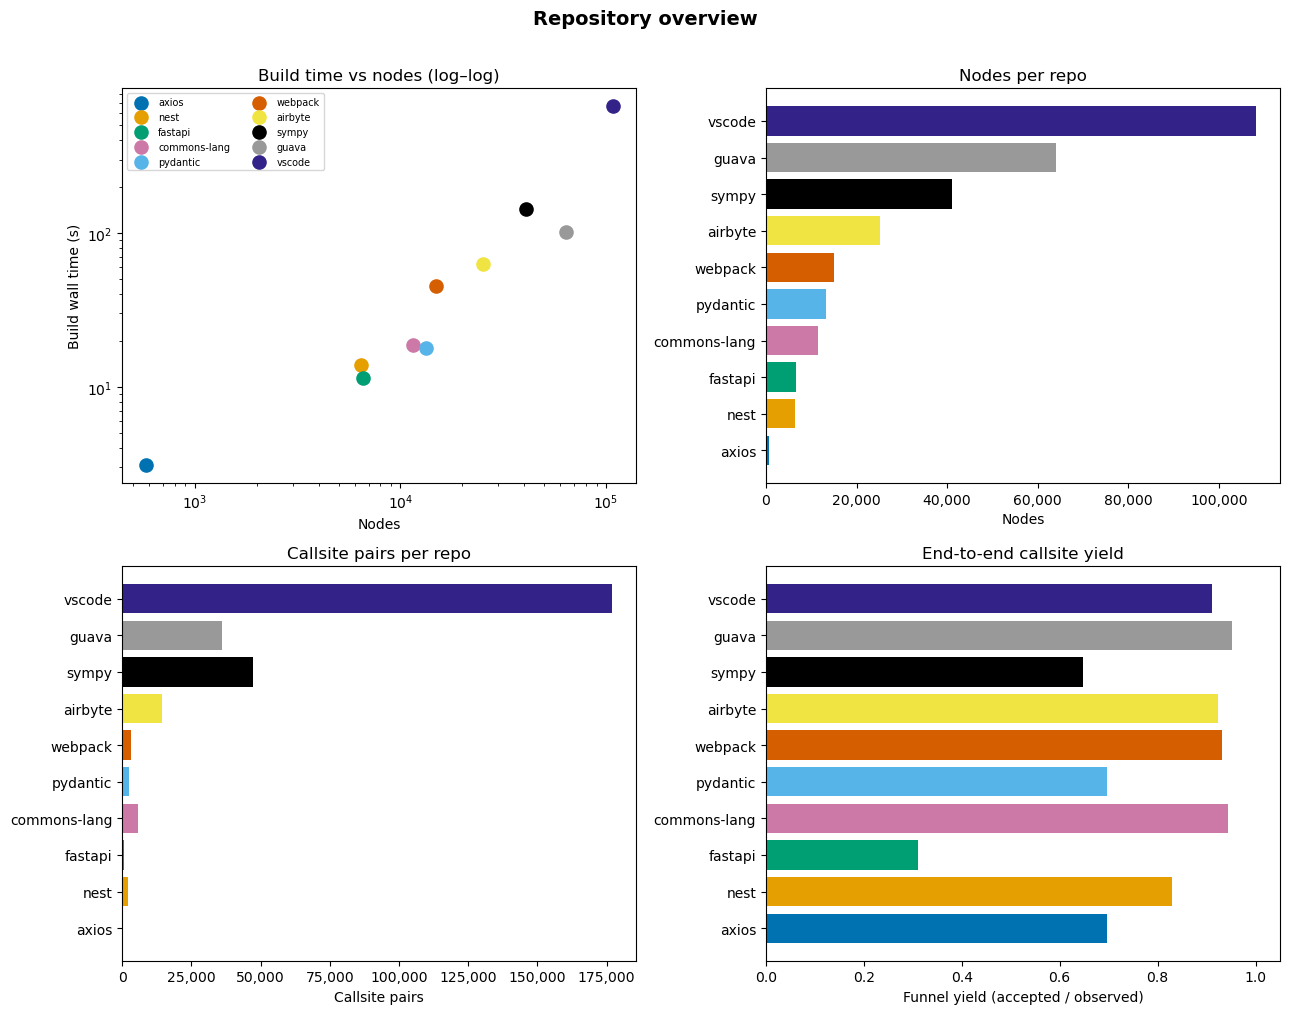

In [173]:
# ── 3c. Repository size overview — 4-panel chart ──────────────────────────────
df = repo_df.sort_values("nodes")
color_map = {repo: PALETTE[i % len(PALETTE)] for i, repo in enumerate(df.index)}
colors = [color_map[r] for r in df.index]

fig, axes = plt.subplots(2, 2, figsize=(13, 10))
fig.suptitle("Repository overview", fontsize=14, fontweight="bold", y=1.01)

# Build time vs nodes (log-log)
ax = axes[0, 0]
for repo, row in df.iterrows():
    ax.scatter(row["nodes"], row["build_wall_seconds"],
               color=color_map[repo], label=repo, s=90, zorder=3)
ax.set_xscale("log"); ax.set_yscale("log")
ax.set_xlabel("Nodes"); ax.set_ylabel("Build wall time (s)")
ax.set_title("Build time vs nodes (log–log)")
ax.legend(fontsize=7, ncol=2, loc="upper left")

# Nodes by repo
ax = axes[0, 1]
ax.barh(df.index, df["nodes"], color=colors)
ax.set_xlabel("Nodes"); ax.set_title("Nodes per repo")
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:,.0f}"))

# Callsite pairs by repo
ax = axes[1, 0]
ax.barh(df.index, df["callsite_pairs"], color=colors)
ax.set_xlabel("Callsite pairs"); ax.set_title("Callsite pairs per repo")
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:,.0f}"))

# Funnel yield by repo
ax = axes[1, 1]
ax.barh(df.index, df["funnel_yield"], color=colors)
ax.set_xlabel("Funnel yield (accepted / observed)")
ax.set_title("End-to-end callsite yield")
ax.set_xlim(0, 1.05)

plt.tight_layout()
plt.show()

---
## 4  Per-language breakdown

In [174]:
# ── 4a. Language presence matrix ──────────────────────────────────────────────
lang_presence = lang_df.pivot_table(
    index="repo", columns="language", values="files", aggfunc="sum"
).fillna(0).astype(int)
lang_presence["total_files"] = lang_presence.sum(axis=1)
lang_presence.sort_values("total_files", ascending=False)

language,java,javascript,python,typescript,total_files
repo,,,,,
webpack,0,8615,0,88,8703
vscode,1,105,3,6656,6765
airbyte,473,44,2768,3,3288
guava,3243,2,0,0,3245
nest,0,49,0,1659,1708
sympy,0,0,1590,0,1590
fastapi,0,3,1284,0,1287
commons-lang,534,0,0,0,534
pydantic,0,6,401,0,407


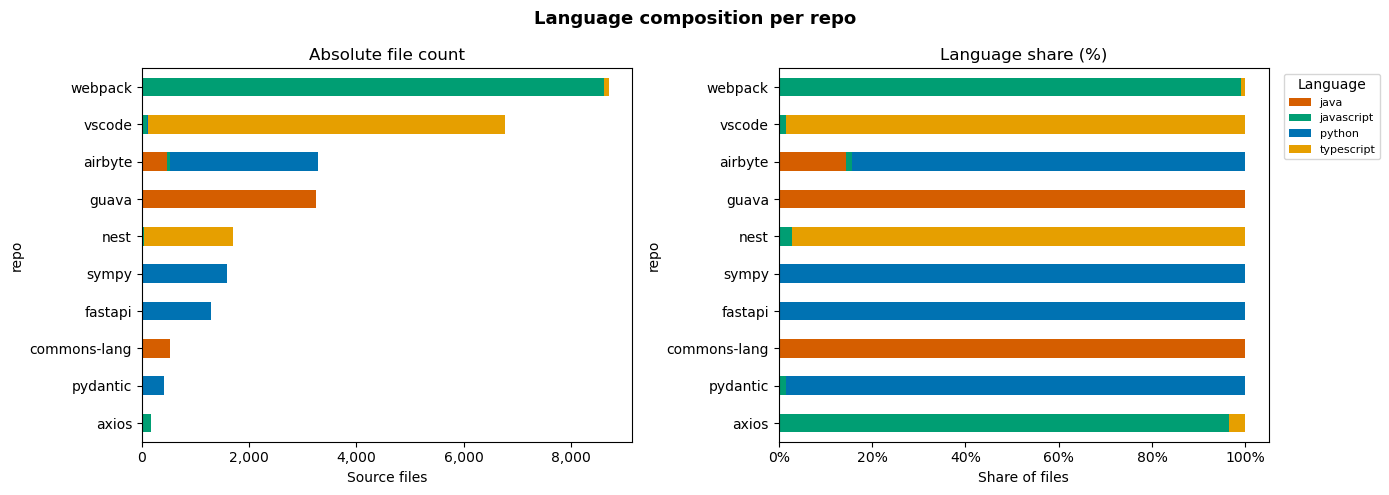

In [175]:
# ── 4b. Per-repo language composition (stacked bar) ───────────────────────────
lang_file_pivot = lang_df.pivot_table(
    index="repo", columns="language", values="files", aggfunc="sum"
).fillna(0)
lang_file_pivot = lang_file_pivot.loc[lang_file_pivot.sum(axis=1).sort_values().index]

langs = lang_file_pivot.columns.tolist()
bar_colors = [LANG_COLORS.get(l, LANG_COLORS["other"]) for l in langs]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Language composition per repo", fontsize=13, fontweight="bold")

# Absolute files
lang_file_pivot.plot(kind="barh", stacked=True, ax=axes[0], color=bar_colors, legend=False)
axes[0].set_xlabel("Source files")
axes[0].set_title("Absolute file count")
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:,.0f}"))

# Percentage share
lang_pct = lang_file_pivot.div(lang_file_pivot.sum(axis=1), axis=0)
lang_pct.plot(kind="barh", stacked=True, ax=axes[1], color=bar_colors)
axes[1].set_xlabel("Share of files")
axes[1].set_title("Language share (%)")
axes[1].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:.0%}"))
axes[1].legend(title="Language", bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=8)

plt.tight_layout()
plt.show()

In [176]:
# ── 4c. Per-language aggregate summary (across all repos) ─────────────────────
lang_agg = lang_df.groupby("language").agg(
    repos=("repo", "nunique"),
    files=("files", "sum"),
    nodes=("nodes", "sum"),
    edges=("edges", "sum"),
    callsite_pairs=("callsite_pairs", "sum"),
    finalized_call_edges=("finalized_call_edges", "sum"),
    filter_rate=("filter_rate", "mean"),
    drop_rate=("drop_rate", "mean"),
    funnel_yield=("funnel_yield", "mean"),
    nodes_per_file=("nodes_per_file", "mean"),
    edge_to_node_ratio=("edge_to_node_ratio", "mean"),
).round(4)
lang_agg

,repos,files,nodes,edges,callsite_pairs,finalized_call_edges,filter_rate,drop_rate,funnel_yield,nodes_per_file,edge_to_node_ratio
language,,,,,,,,,,,
java,4,4251,79844,82648,43385,43345,0.0346,0.0145,0.9514,13.7987,0.9438
javascript,8,8991,15838,12126,3550,3534,0.0486,0.0104,0.9422,3.0819,0.6637
python,5,6046,81834,94157,62898,61498,0.2852,0.1277,0.6418,15.2544,1.0335
typescript,5,8412,114375,179398,178948,177255,0.0528,0.0138,0.9349,9.5625,1.0212


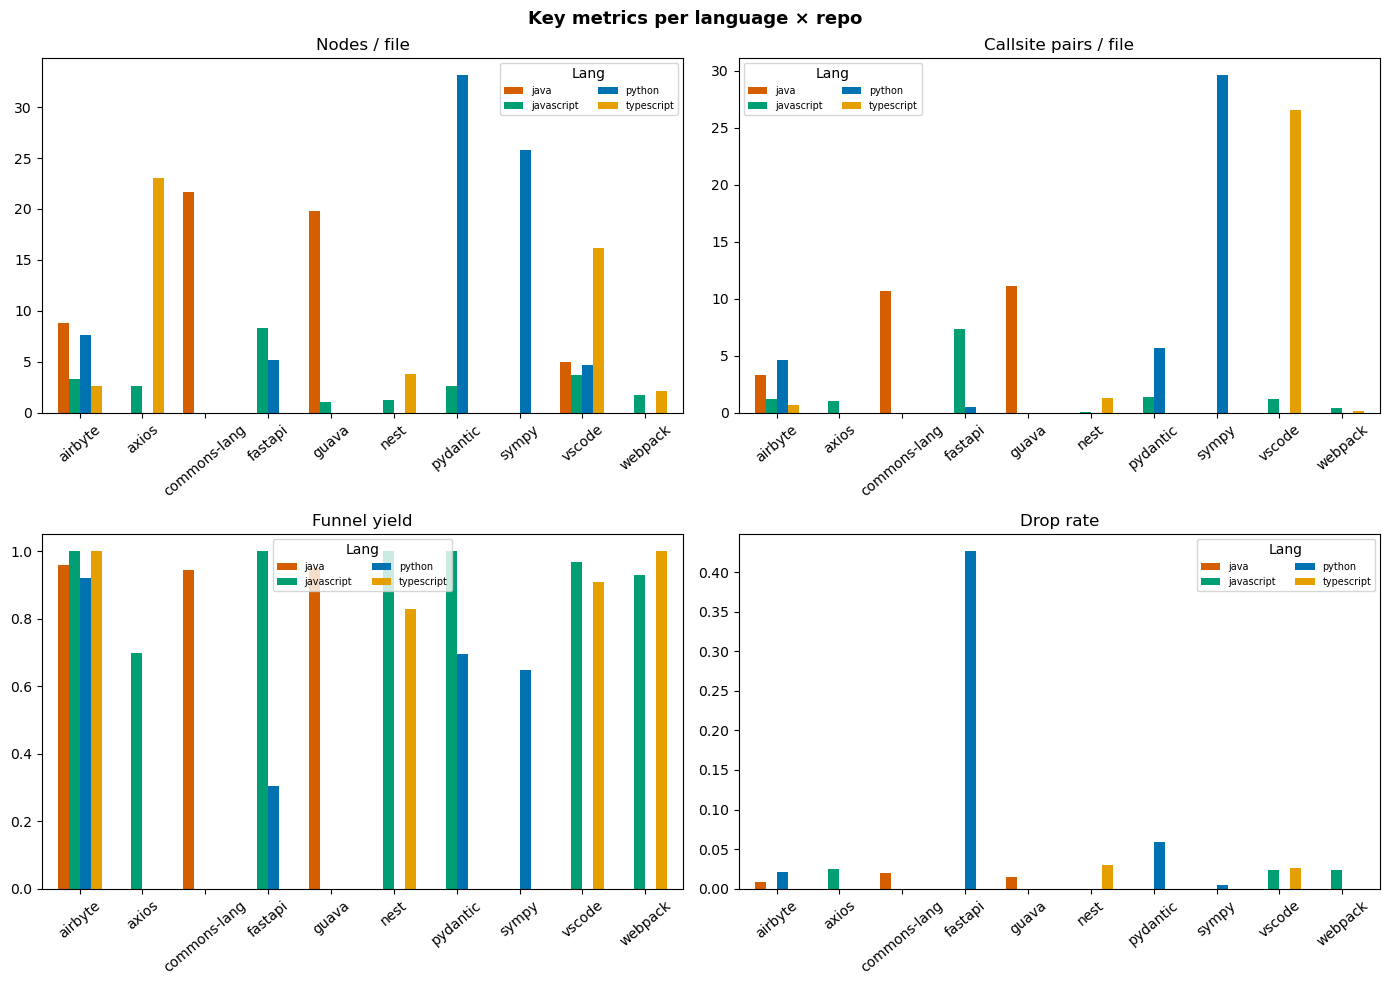

In [177]:
# ── 4d. Key metrics per language — grouped repo view ─────────────────────────
metrics = [
    ("nodes_per_file",   "Nodes / file"),
    ("callsites_per_file", "Callsite pairs / file"),
    ("funnel_yield",     "Funnel yield"),
    ("drop_rate",        "Drop rate"),
]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("Key metrics per language × repo", fontsize=13, fontweight="bold")

for ax, (col, title) in zip(axes.flat, metrics):
    pivot = lang_df.pivot_table(index="repo", columns="language", values=col)
    langs_here = pivot.columns.tolist()
    cmap = [LANG_COLORS.get(l, LANG_COLORS["other"]) for l in langs_here]
    pivot.sort_index().plot(kind="bar", ax=ax, color=cmap, width=0.7)
    ax.set_title(title)
    ax.set_xlabel("")
    ax.tick_params(axis="x", rotation=40)
    ax.legend(title="Lang", fontsize=7, ncol=2)

plt.tight_layout()
plt.show()

---
## 5  Scope breakdown — non-tests vs tests

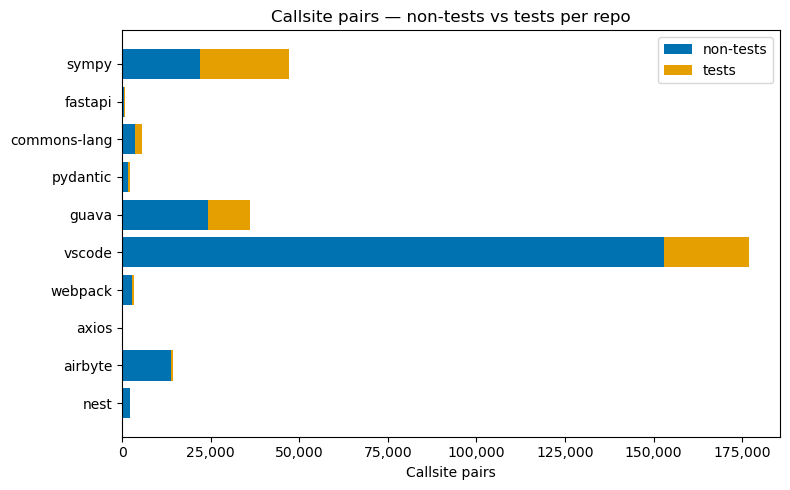

,cs_non_tests,cs_tests,test_callsite_share
repo,,,
sympy,21987,25122,0.5333
fastapi,453,263,0.3673
commons-lang,3667,2051,0.3587
pydantic,1499,774,0.3405
guava,24194,11905,0.3298
vscode,152896,23960,0.1355
webpack,2809,380,0.1192
axios,158,7,0.0424
airbyte,13848,605,0.0419


In [178]:
# ── 5a. Test callsite share per repo ──────────────────────────────────────────
df = repo_df.sort_values("test_callsite_share", ascending=True)
fig, ax = plt.subplots(figsize=(8, 5))

ax.barh(df.index, df["cs_non_tests"], color="#0072B2", label="non-tests")
ax.barh(df.index, df["cs_tests"], left=df["cs_non_tests"], color="#E69F00", label="tests")
ax.set_xlabel("Callsite pairs")
ax.set_title("Callsite pairs — non-tests vs tests per repo")
ax.legend()
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:,.0f}"))
plt.tight_layout()
plt.show()

repo_df[["cs_non_tests", "cs_tests", "test_callsite_share"]].sort_values("test_callsite_share", ascending=False)

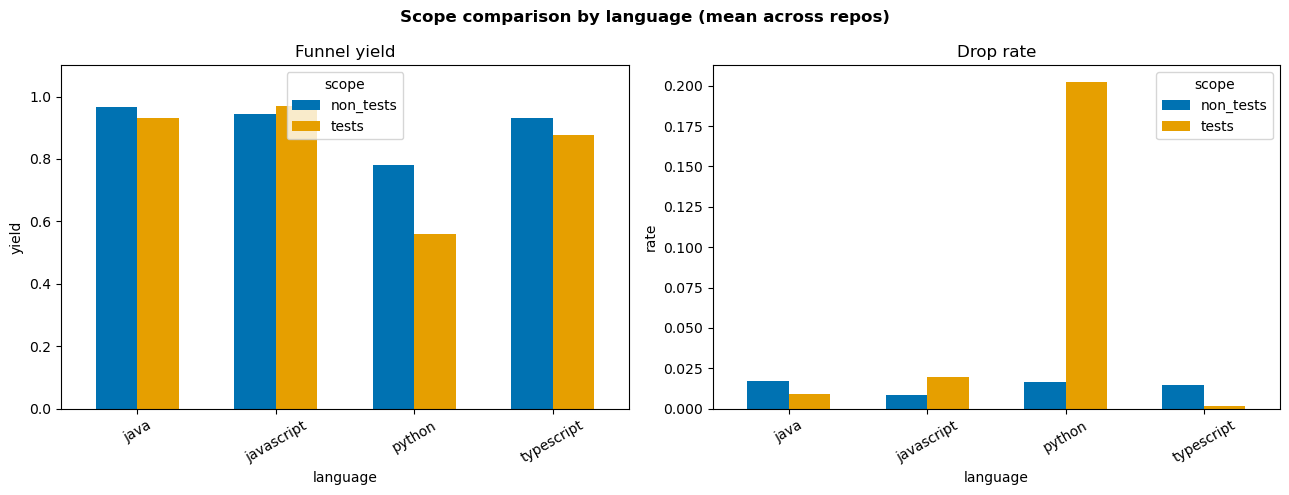

In [179]:
# ── 5b. Funnel yield: non-tests vs tests, per language ─────────────────────────
scope_yield = scope_df.groupby(["language", "scope"])["funnel_yield"].mean().unstack()
scope_drop  = scope_df.groupby(["language", "scope"])["drop_rate"].mean().unstack()

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle("Scope comparison by language (mean across repos)", fontsize=12, fontweight="bold")

scope_yield.plot(kind="bar", ax=axes[0], color=["#0072B2", "#E69F00"], width=0.6)
axes[0].set_title("Funnel yield")
axes[0].set_ylabel("yield")
axes[0].set_ylim(0, 1.1)
axes[0].tick_params(axis="x", rotation=30)

scope_drop.plot(kind="bar", ax=axes[1], color=["#0072B2", "#E69F00"], width=0.6)
axes[1].set_title("Drop rate")
axes[1].set_ylabel("rate")
axes[1].tick_params(axis="x", rotation=30)

plt.tight_layout()
plt.show()

In [180]:
# ── 5c. Scope split detail table (repo × language × scope) ────────────────────
scope_detail = scope_df.pivot_table(
    index=["repo", "language"],
    columns="scope",
    values=["callsite_pairs", "funnel_yield", "drop_rate"]
).round(4)
scope_detail

callsite_pairs            drop_rate        funnel_yield       
scope                        non_tests      tests non_tests  tests    non_tests  tests
repo         language                                                                 
airbyte      java            1108.0000   460.0000    0.0117 0.0000       0.9456 0.9914
             javascript        53.0000     0.0000    0.0000    NaN       1.0000    NaN
             python         12685.0000   145.0000    0.0210 0.0268       0.9193 0.9667
             typescript         2.0000     0.0000    0.0000    NaN       1.0000    NaN
axios        javascript       158.0000     7.0000    0.0253 0.0000       0.6875 1.0000
commons-lang java            3667.0000  2051.0000    0.0209 0.0191       0.9771 0.8960
fastapi      javascript        22.0000     0.0000    0.0000    NaN       1.0000    NaN
             python           431.0000   263.0000    0.0160 0.6593       0.6011 0.1674
guava        java           24194.0000 11905.0000    0.0188 0.0074       0.9738 0.9100
nest         javascript         2.0000     0.0000    0.0000    NaN       1.0000    NaN
             typescript      2194.0000     7.0000    0.0295 0.0000       0.8296 0.7778
pydantic     javascript         5.0000     3.0000    0.0000 0.0000       1.0000 1.0000
             python          1494.0000   771.0000    0.0248 0.1189       0.8155 0.5418
sympy        python         21987.0000 25122.0000    0.0039 0.0049       0.7866 0.5619
vscode       javascript        87.0000    36.0000    0.0116 0.0526       0.9884 0.9231
             typescript    152809.0000 23924.0000    0.0298 0.0039       0.8993 0.9737
webpack      javascript      2797.0000   380.0000    0.0238 0.0256       0.9264 0.9620
             typescript        12.0000     0.0000    0.0000    NaN       1.0000    NaN

---
## 6  Callsite funnel analysis

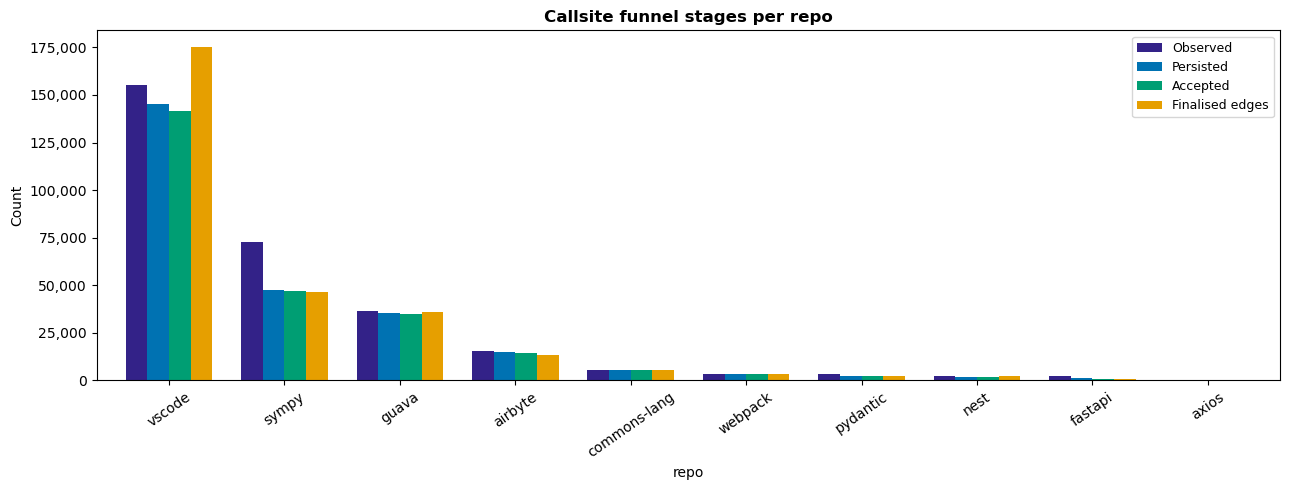

In [181]:
# ── 6a. Funnel stages — absolute counts per repo ──────────────────────────────
funnel_cols = [
    "observed_callsites", "persisted_callsites",
    "persisted_accepted", "finalized_call_edges"
]
funnel_labels = ["Observed", "Persisted", "Accepted", "Finalised edges"]

funnel_df = repo_df[funnel_cols].sort_values("observed_callsites", ascending=False)
funnel_df.columns = funnel_labels

ax = funnel_df.plot(kind="bar", figsize=(13, 5), width=0.75,
                    color=["#332288", "#0072B2", "#009E73", "#E69F00"])
ax.set_title("Callsite funnel stages per repo", fontweight="bold")
ax.set_ylabel("Count")
ax.tick_params(axis="x", rotation=35)
ax.legend(loc="upper right", fontsize=9)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:,.0f}"))
plt.tight_layout()
plt.show()

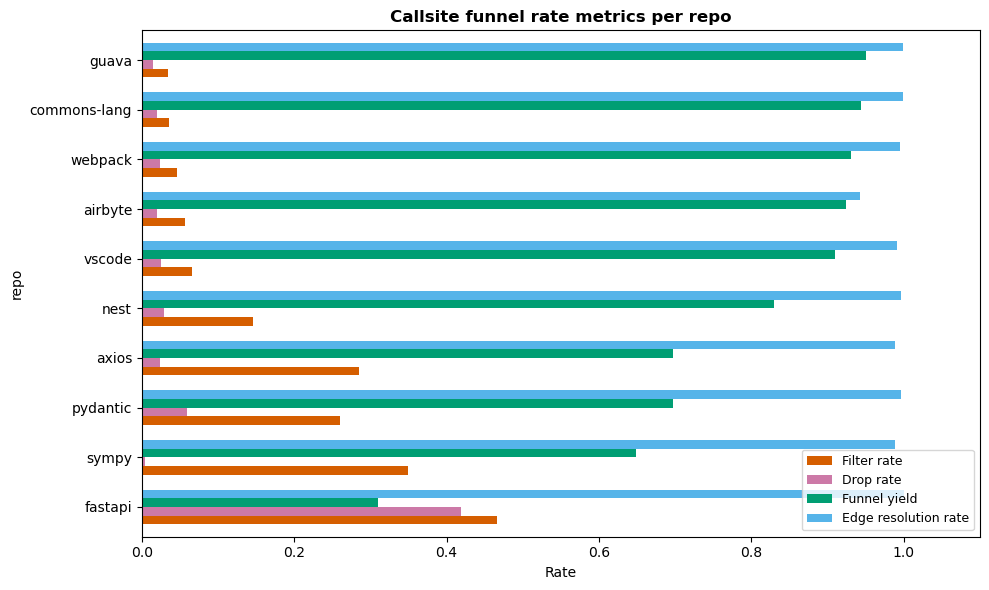

,filter_rate,drop_rate,funnel_yield,edge_resolution_rate
repo,,,,
guava,0.0346,0.0150,0.9510,0.9990
commons-lang,0.0360,0.0202,0.9445,0.9991
webpack,0.0463,0.0240,0.9308,0.9956
airbyte,0.0573,0.0196,0.9242,0.9419
vscode,0.0657,0.0259,0.9102,0.9905
nest,0.1453,0.0293,0.8296,0.9964
axios,0.2857,0.0242,0.6970,0.9879
pydantic,0.2599,0.0588,0.6966,0.9960
sympy,0.3488,0.0044,0.6483,0.9883


In [182]:
# ── 6b. Rate metrics per repo ──────────────────────────────────────────────────
rate_cols = ["filter_rate", "drop_rate", "funnel_yield", "edge_resolution_rate"]
rate_labels = ["Filter rate", "Drop rate", "Funnel yield", "Edge resolution rate"]

rate_df = repo_df[rate_cols].sort_values("funnel_yield", ascending=True)
rate_df.columns = rate_labels

ax = rate_df.plot(kind="barh", figsize=(10, 6), width=0.7,
                  color=["#D55E00", "#CC79A7", "#009E73", "#56B4E9"])
ax.set_title("Callsite funnel rate metrics per repo", fontweight="bold")
ax.set_xlabel("Rate")
ax.set_xlim(0, 1.1)
ax.legend(loc="lower right", fontsize=9)
plt.tight_layout()
plt.show()

repo_df[rate_cols].round(4).sort_values("funnel_yield", ascending=False)

In [183]:
# ── 6c. Per-language funnel rates (mean ± std across repos) ────────────────────
lang_funnel = lang_df.groupby("language")[["filter_rate", "drop_rate", "funnel_yield"]].agg(["mean", "std"])
lang_funnel.columns = ["_".join(c) for c in lang_funnel.columns]
lang_funnel.round(4)

,filter_rate_mean,filter_rate_std,drop_rate_mean,drop_rate_std,funnel_yield_mean,funnel_yield_std
language,,,,,,
java,0.0346,0.0014,0.0145,0.0060,0.9514,0.0071
javascript,0.0486,0.1059,0.0104,0.0129,0.9422,0.1113
python,0.2852,0.1730,0.1277,0.2004,0.6418,0.2548
typescript,0.0528,0.0691,0.0138,0.0160,0.9349,0.0821


In [184]:
# ── 6d. conservation_ok flag check ────────────────────────────────────────────
conservation_issues = []
for repo, r in reports.items():
    t = r["summary"]["totals"]
    ok = t["call_site_funnel"].get("conservation_ok", None)
    if not ok:
        conservation_issues.append({"repo": repo, "scope": "total", "conservation_ok": ok})
    for scope in ("non_tests", "tests"):
        ok_s = t["call_site_funnel_by_scope"][scope].get("conservation_ok", None)
        if not ok_s:
            conservation_issues.append({"repo": repo, "scope": scope, "conservation_ok": ok_s})
    for lang in r["summary"]["languages"]:
        ok_l = lang["call_site_funnel"].get("conservation_ok", None)
        if not ok_l:
            conservation_issues.append({"repo": repo, "language": lang["language"], "scope": "total", "conservation_ok": ok_l})

if conservation_issues:
    print("⚠️  conservation_ok violations found:")
    display(pd.DataFrame(conservation_issues))
else:
    print("✅  All conservation_ok flags are True across all repos, languages, and scopes.")

✅  All conservation_ok flags are True across all repos, languages, and scopes.


---
## 7  Callsite pair expansion

In [185]:
# ── 7a. Pair expansion overview table ─────────────────────────────────────────
exp_cols = ["pair_expansion_factor", "multi_pair_share", "max_pairs_single_callsite"]
repo_df[exp_cols].sort_values("pair_expansion_factor").round(5)

,pair_expansion_factor,multi_pair_share,max_pairs_single_callsite
repo,,,
fastapi,0.5812,0.0000,1
pydantic,0.9412,0.0000,1
airbyte,0.9812,0.0004,2
webpack,0.9928,0.0056,5
sympy,0.9956,0.0000,1
axios,1.0000,0.0121,2
guava,1.0205,0.0100,34
commons-lang,1.0421,0.0126,10
nest,1.0955,0.0224,16


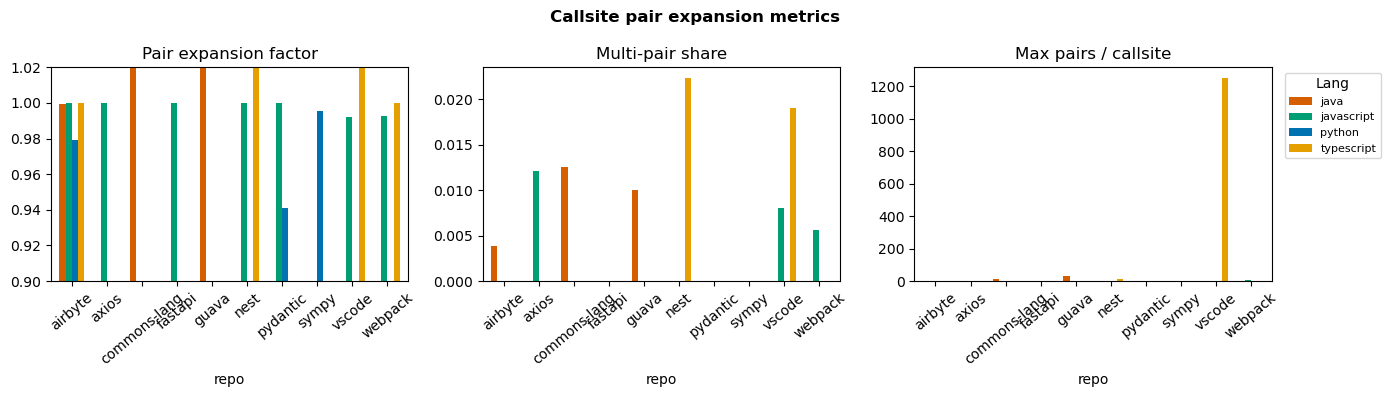

In [186]:
# ── 7b. Expansion factor distribution across languages ─────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
fig.suptitle("Callsite pair expansion metrics", fontsize=12, fontweight="bold")

pivot_ef  = lang_df.pivot_table(index="repo", columns="language", values="pair_expansion_factor")
pivot_mps = lang_df.pivot_table(index="repo", columns="language", values="multi_pair_share")
pivot_max = lang_df.pivot_table(index="repo", columns="language", values="max_pairs_single_callsite")

def get_colors(df):
    return [LANG_COLORS.get(l, LANG_COLORS["other"]) for l in df.columns]

pivot_ef.sort_index().plot(kind="bar", ax=axes[0], color=get_colors(pivot_ef), width=0.7, legend=False)
axes[0].set_title("Pair expansion factor"); axes[0].tick_params(axis="x", rotation=40)
axes[0].set_ylim(0.9, 1.02)

pivot_mps.sort_index().plot(kind="bar", ax=axes[1], color=get_colors(pivot_mps), width=0.7, legend=False)
axes[1].set_title("Multi-pair share"); axes[1].tick_params(axis="x", rotation=40)

pivot_max.sort_index().plot(kind="bar", ax=axes[2], color=get_colors(pivot_max), width=0.7)
axes[2].set_title("Max pairs / callsite"); axes[2].tick_params(axis="x", rotation=40)
axes[2].legend(title="Lang", bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=8)

plt.tight_layout()
plt.show()

In [187]:
# ── 7c. Expansion factor: non-tests vs tests ───────────────────────────────────
exp_scope = scope_df.groupby(["repo", "scope"])["pair_expansion_factor"].mean().unstack()
exp_scope.sort_values("non_tests", ascending=False).round(5)

scope,non_tests,tests
repo,,
vscode,1.1271,1.0141
commons-lang,1.0798,0.9809
nest,1.0479,1.0000
guava,1.0349,0.9926
axios,1.0000,1.0000
webpack,0.9977,0.9744
sympy,0.9961,0.9951
airbyte,0.9945,0.9866
fastapi,0.9920,0.3407


---
## 8  Graph metrics — nodes, edges, density

In [188]:
# ── 8a. Node and edge density overview ────────────────────────────────────────
graph_cols = ["files", "nodes", "edges", "nodes_per_file",
               "callsites_per_file", "edge_to_node_ratio",
               "low_node_file_ratio"]
repo_df[graph_cols].sort_values("nodes", ascending=False).round(4)

,files,nodes,edges,nodes_per_file,callsites_per_file,edge_to_node_ratio,low_node_file_ratio
repo,,,,,,,
vscode,6765,108097,171474,15.9789,26.1428,1.5863,0.2229
guava,3245,64131,67212,19.7630,11.1245,1.0480,0.0450
sympy,1590,40980,52633,25.7736,29.6283,1.2844,0.1371
airbyte,3288,25275,24450,7.6870,4.3957,0.9674,0.2232
webpack,8703,14945,11253,1.7172,0.3664,0.7530,0.8373
pydantic,407,13301,14019,32.6806,5.5848,1.0540,0.0885
commons-lang,534,11566,11603,21.6592,10.7079,1.0032,0.0487
fastapi,1287,6604,7038,5.1313,0.5563,1.0657,0.1639
nest,1708,6416,8005,3.7564,1.2898,1.2477,0.3126


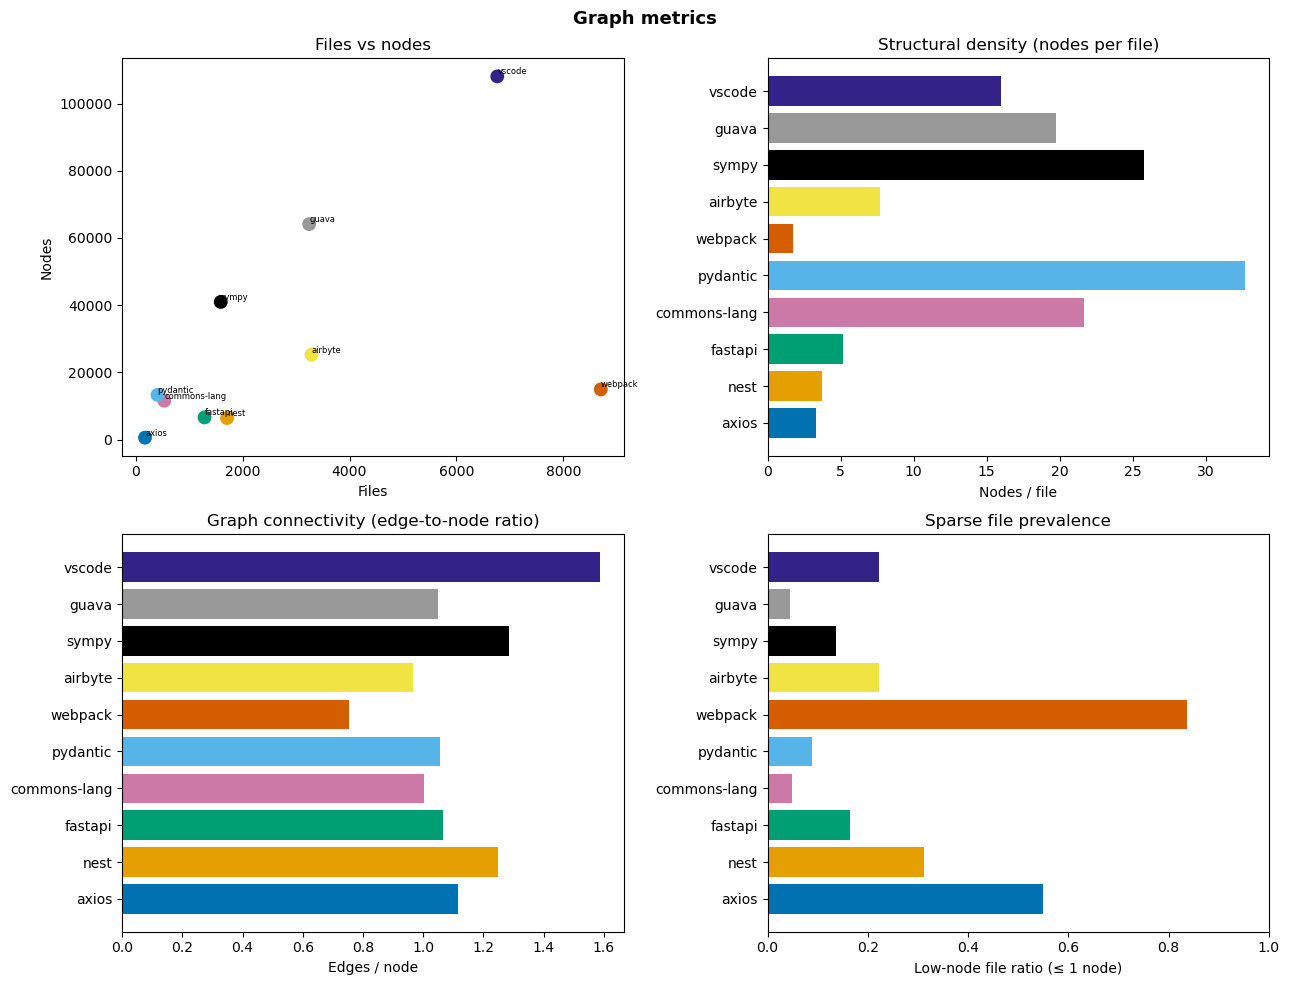

In [189]:
# ── 8b. Graph density — 4-panel scatter / bar ─────────────────────────────────
df = repo_df.sort_values("nodes")
color_map = {repo: PALETTE[i % len(PALETTE)] for i, repo in enumerate(df.index)}
colors = [color_map[r] for r in df.index]

fig, axes = plt.subplots(2, 2, figsize=(13, 10))
fig.suptitle("Graph metrics", fontsize=13, fontweight="bold")

# Files vs nodes
ax = axes[0, 0]
ax.scatter(df["files"], df["nodes"], c=colors, s=80, zorder=3)
for repo, row in df.iterrows():
    ax.annotate(repo, (row["files"], row["nodes"]), fontsize=6, ha="left", va="bottom")
ax.set_xlabel("Files"); ax.set_ylabel("Nodes")
ax.set_title("Files vs nodes")

# Nodes per file by repo
ax = axes[0, 1]
ax.barh(df.index, df["nodes_per_file"], color=colors)
ax.set_xlabel("Nodes / file")
ax.set_title("Structural density (nodes per file)")

# Edge-to-node ratio
ax = axes[1, 0]
ax.barh(df.index, df["edge_to_node_ratio"], color=colors)
ax.set_xlabel("Edges / node")
ax.set_title("Graph connectivity (edge-to-node ratio)")

# Low-node file ratio
ax = axes[1, 1]
ax.barh(df.index, df["low_node_file_ratio"], color=colors)
ax.set_xlabel("Low-node file ratio (≤ 1 node)")
ax.set_title("Sparse file prevalence")
ax.set_xlim(0, 1)

plt.tight_layout()
plt.show()

In [190]:
# ── 8c. Per-language density stats ────────────────────────────────────────────
lang_density = lang_df.groupby("language").agg(
    mean_nodes_per_file=("nodes_per_file", "mean"),
    std_nodes_per_file=("nodes_per_file", "std"),
    mean_callsites_per_file=("callsites_per_file", "mean"),
    mean_edge_to_node=("edge_to_node_ratio", "mean"),
    mean_low_node_ratio=("low_node_file_ratio", "mean"),
).round(4)
lang_density

,mean_nodes_per_file,std_nodes_per_file,mean_callsites_per_file,mean_edge_to_node,mean_low_node_ratio
language,,,,,
java,13.7987,8.1709,6.2886,0.9438,0.0233
javascript,3.0819,2.3310,1.5550,0.6637,0.5973
python,15.2544,13.2649,8.0905,1.0335,0.1952
typescript,9.5625,9.4855,5.7364,1.0212,0.3963


---
## 9  Pre-persist filter buckets

In [191]:
# ── 9a. Filter bucket absolute counts per repo ────────────────────────────────
fpp_cols = ["fpp_no_repo_terminal", "fpp_no_repo_qualified",
             "fpp_accepted_outside", "fpp_invalid_shape", "fpp_total"]
fpp_df = repo_df[fpp_cols].sort_values("fpp_total", ascending=False)
fpp_df

,fpp_no_repo_terminal,fpp_no_repo_qualified,fpp_accepted_outside,fpp_invalid_shape,fpp_total
repo,,,,,
sympy,0,25344,0,0,25344
vscode,0,10208,0,0,10208
guava,0,1266,0,0,1266
fastapi,0,1078,0,0,1078
airbyte,0,896,0,0,896
pydantic,0,848,0,0,848
nest,0,342,0,0,342
commons-lang,0,205,0,0,205
webpack,0,156,0,0,156


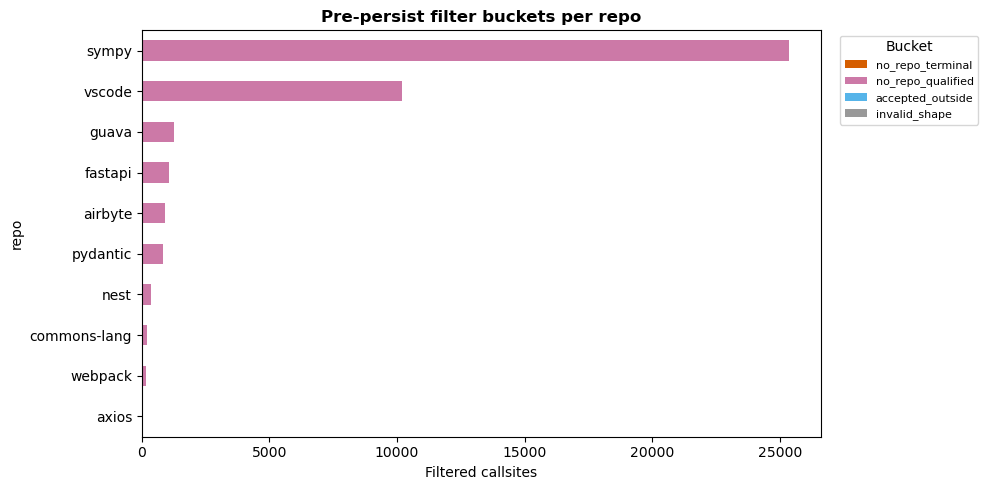

In [192]:
# ── 9b. Filter bucket stacked bar ─────────────────────────────────────────────
plot_cols  = ["fpp_no_repo_terminal", "fpp_no_repo_qualified",
               "fpp_accepted_outside", "fpp_invalid_shape"]
plot_labels = ["no_repo_terminal", "no_repo_qualified",
                "accepted_outside", "invalid_shape"]

fpp_plot = fpp_df[plot_cols].copy()
fpp_plot.columns = plot_labels
fpp_plot["_total"] = fpp_plot.sum(axis=1)
fpp_plot = fpp_plot.sort_values("_total", ascending=True).drop(columns="_total")

ax = fpp_plot.plot(kind="barh", stacked=True, figsize=(10, 5),
                    color=["#D55E00", "#CC79A7", "#56B4E9", "#999999"])
ax.set_title("Pre-persist filter buckets per repo", fontweight="bold")
ax.set_xlabel("Filtered callsites")
ax.legend(title="Bucket", bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=8)
plt.tight_layout()
plt.show()

In [193]:
# ── 9c. Filter bucket rates per repo ──────────────────────────────────────────
for col in ["fpp_no_repo_terminal", "fpp_no_repo_qualified",
             "fpp_accepted_outside", "fpp_invalid_shape", "fpp_total"]:
    repo_df[col + "_rate"] = repo_df[col] / repo_df["observed_callsites"]

rate_fpp_cols = [c + "_rate" for c in plot_cols]
repo_df[rate_fpp_cols + ["fpp_total_rate"]].sort_values("fpp_total_rate", ascending=False).round(5)

,fpp_no_repo_terminal_rate,fpp_no_repo_qualified_rate,fpp_accepted_outside_rate,fpp_invalid_shape_rate,fpp_total_rate
repo,,,,,
fastapi,0.0000,0.4667,0.0000,0.0000,0.4667
sympy,0.0000,0.3488,0.0000,0.0000,0.3488
axios,0.0000,0.2857,0.0000,0.0000,0.2857
pydantic,0.0000,0.2599,0.0000,0.0000,0.2599
nest,0.0000,0.1454,0.0000,0.0000,0.1454
vscode,0.0000,0.0657,0.0000,0.0000,0.0657
airbyte,0.0000,0.0573,0.0000,0.0000,0.0573
webpack,0.0000,0.0463,0.0000,0.0000,0.0463
commons-lang,0.0000,0.0360,0.0000,0.0000,0.0360


In [194]:
# ── 9d. Per-language filter bucket totals ─────────────────────────────────────
lang_fpp = lang_df.groupby("language")[
    ["fpp_no_repo_terminal", "fpp_no_repo_qualified",
      "fpp_accepted_outside",  "fpp_invalid_shape"]
].sum()
lang_fpp["total"] = lang_fpp.sum(axis=1)
lang_fpp

,fpp_no_repo_terminal,fpp_no_repo_qualified,fpp_accepted_outside,fpp_invalid_shape,total
language,,,,,
java,0,1525,0,0,1525
javascript,0,223,0,0,223
python,0,28112,0,0,28112
typescript,0,10549,0,0,10549


---
## 10  Build performance

In [195]:
# ── 10a. Phase timing flat frame ──────────────────────────────────────────────
phase_rows = []
for repo, r in reports.items():
    for phase, seconds in r["summary"]["build_phase_timings"].items():
        phase_rows.append({"repo": repo, "phase": phase, "seconds": seconds})

phase_df = pd.DataFrame(phase_rows)

phase_wide = phase_df.pivot(index="repo", columns="phase", values="seconds").fillna(0)
phase_wide["total"] = phase_wide.sum(axis=1)
phase_wide.sort_values("total", ascending=False)

phase,build_structural_index,compute_build_fingerprint,derive_call_artifacts,discover_files,prepare_callsite_pairs,prepare_snapshots,rebuild_graph_index,rebuild_graph_rollups,register_modules,write_callsite_pairs,total
repo,,,,,,,,,,,
vscode,132.7606,0.6581,119.4211,2.6406,286.6479,1.3542,10.0781,6.6486,2.8365,14.4400,577.4858
sympy,40.4138,0.3488,38.6184,0.6810,35.1633,0.3205,2.1415,1.6407,0.5778,2.8627,122.7686
guava,34.2233,0.4444,26.6527,1.1240,1.9888,0.6469,2.5691,2.4725,1.3353,2.4100,73.8672
airbyte,21.5154,0.5394,19.2703,2.2190,0.8683,0.5903,0.8103,0.8550,1.2609,0.5889,48.5178
webpack,13.6961,0.3285,13.6620,2.2687,0.1635,1.4613,0.2373,0.2695,2.8451,0.0923,35.0242
commons-lang,6.8235,0.2667,5.7021,0.3331,0.2712,0.1227,0.2680,0.3192,0.2043,0.2100,14.5207
pydantic,7.1265,0.2749,5.6274,0.2722,0.1409,0.0810,0.2518,0.2749,0.1367,0.0763,14.2627
nest,4.3780,0.2617,3.9115,0.5520,0.1655,0.2861,0.1352,0.1492,0.5246,0.0573,10.4211
fastapi,3.6369,0.2551,2.8675,0.5053,0.1269,0.2667,0.1156,0.1202,0.3852,0.0355,8.3150


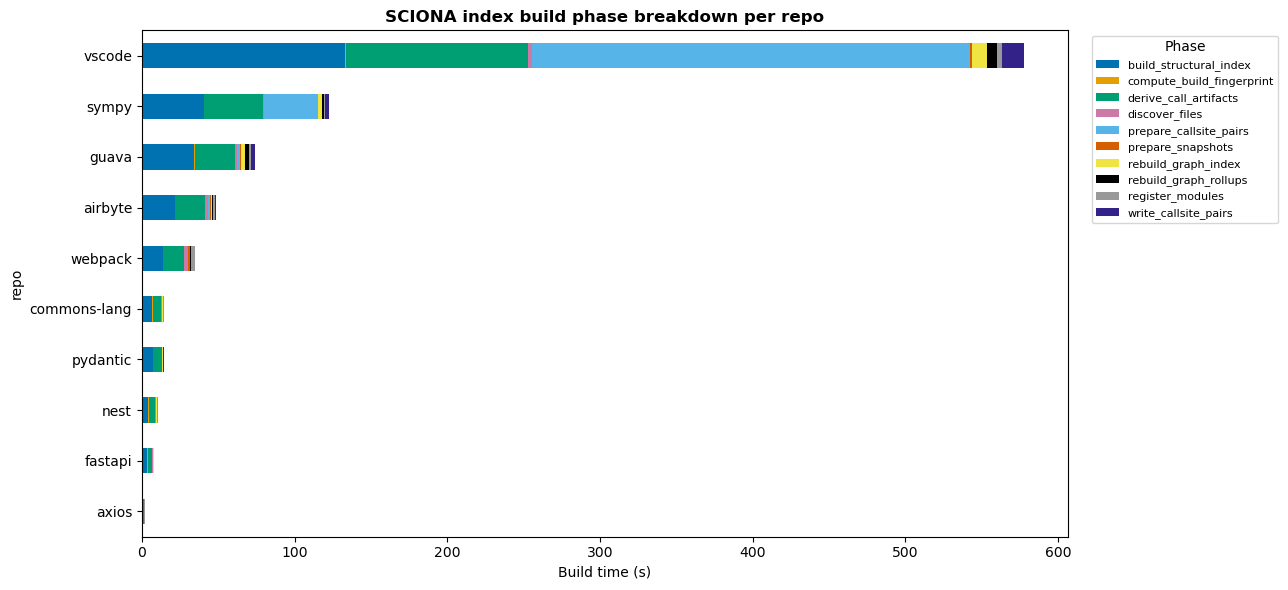

In [196]:
# ── 10b. Phase breakdown stacked bar ──────────────────────────────────────────
phases = [c for c in phase_wide.columns if c != "total"]
phase_plot = phase_wide[phases + ["total"]].sort_values("total", ascending=True).drop(columns="total")

ax = phase_plot.plot(
    kind="barh", stacked=True, figsize=(13, 6),
    color=PALETTE[:len(phases)]
)
ax.set_title("SCIONA index build phase breakdown per repo", fontweight="bold")
ax.set_xlabel("Build time (s)")
ax.legend(title="Phase", bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=8)
plt.tight_layout()
plt.show()

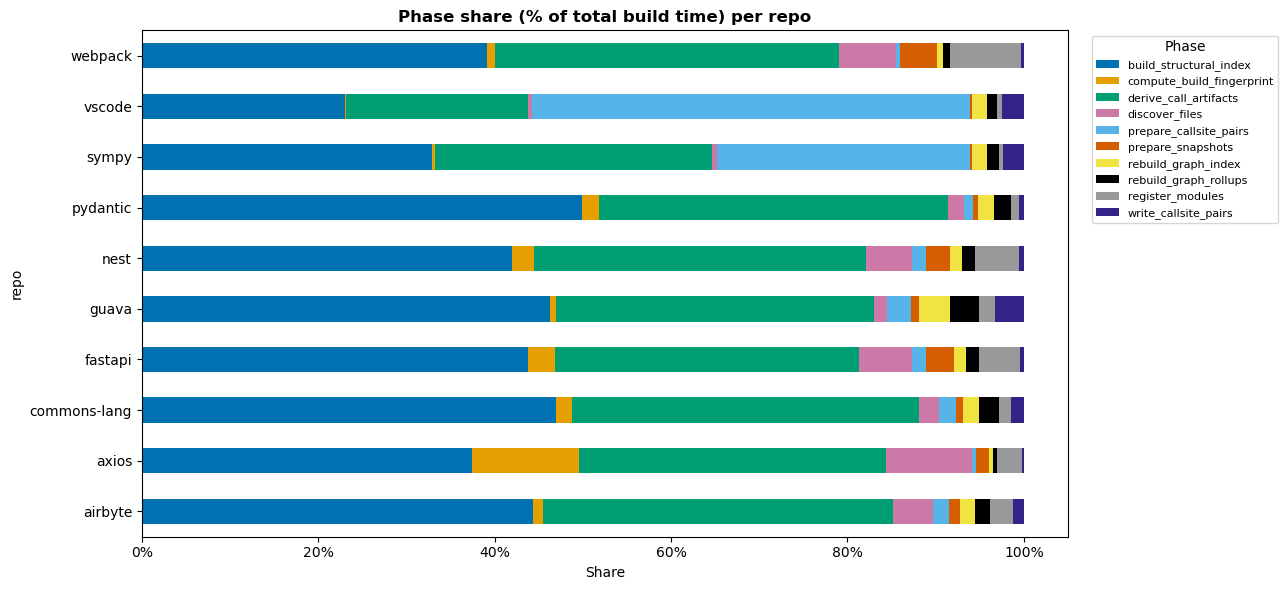

In [197]:
# ── 10c. Phase share (normalised) ─────────────────────────────────────────────
phase_pct = phase_plot.div(phase_wide["total"], axis=0)
ax = phase_pct.plot(
    kind="barh", stacked=True, figsize=(13, 6),
    color=PALETTE[:len(phases)]
)
ax.set_title("Phase share (% of total build time) per repo", fontweight="bold")
ax.set_xlabel("Share")
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:.0%}"))
ax.legend(title="Phase", bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=8)
plt.tight_layout()
plt.show()

In [198]:
# ── 10d. Phase summary — mean time and mean share across repos ─────────────────
phase_mean  = phase_wide[phases].mean().sort_values(ascending=False)
phase_share = phase_pct[phases].mean().sort_values(ascending=False)

phase_summary = pd.DataFrame({
    "mean_seconds": phase_mean,
    "std_seconds":  phase_wide[phases].std(),
    "mean_share":   phase_share,
}).round(3)
phase_summary

,mean_seconds,std_seconds,mean_share
phase,,,
build_structural_index,26.5250,39.6860,0.4060
compute_build_fingerprint,0.3600,0.1440,0.0240
derive_call_artifacts,23.6360,35.7810,0.3530
discover_files,1.0770,0.9400,0.0390
prepare_callsite_pairs,32.5540,89.9450,0.0900
prepare_snapshots,0.5160,0.5120,0.0160
rebuild_graph_index,1.6610,3.0920,0.0160
rebuild_graph_rollups,1.2760,2.0480,0.0160
register_modules,1.0160,1.0550,0.0280


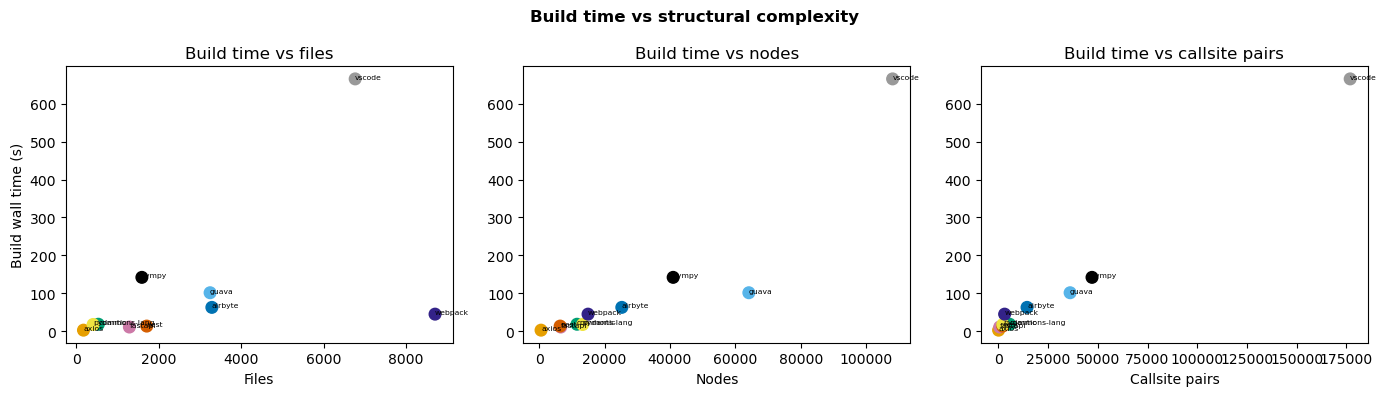

In [199]:
# ── 10e. Build wall time vs structural complexity ─────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
fig.suptitle("Build time vs structural complexity", fontsize=12, fontweight="bold")

df = repo_df.copy()
color_map = {repo: PALETTE[i % len(PALETTE)] for i, repo in enumerate(sorted(df.index))}
colors = [color_map[r] for r in df.index]

for ax, (xcol, xlabel) in zip(axes, [
    ("files",          "Files"),
    ("nodes",          "Nodes"),
    ("callsite_pairs", "Callsite pairs"),
]):
    ax.scatter(df[xcol], df["build_wall_seconds"], c=colors, s=70, zorder=3)
    for repo, row in df.iterrows():
        ax.annotate(repo, (row[xcol], row["build_wall_seconds"]), fontsize=5.5, ha="left")
    ax.set_xlabel(xlabel)
    ax.set_ylabel("Build wall time (s)" if ax == axes[0] else "")
    ax.set_title(f"Build time vs {xlabel.lower()}")

plt.tight_layout()
plt.show()

In [200]:
# ── 10f. Build time aggregate stats ───────────────────────────────────────────
build_stats = repo_df[["build_wall_seconds", "build_total_seconds"]].agg(["mean", "median", "std", "min", "max"]).round(2)
print(build_stats)

        build_wall_seconds  build_total_seconds
mean              108.2600             106.1500
median             32.0100              30.4600
std               200.7800             199.0600
min                 3.1100               2.5200
max               665.1300             658.4400


---
## 11  Cross-metric correlation

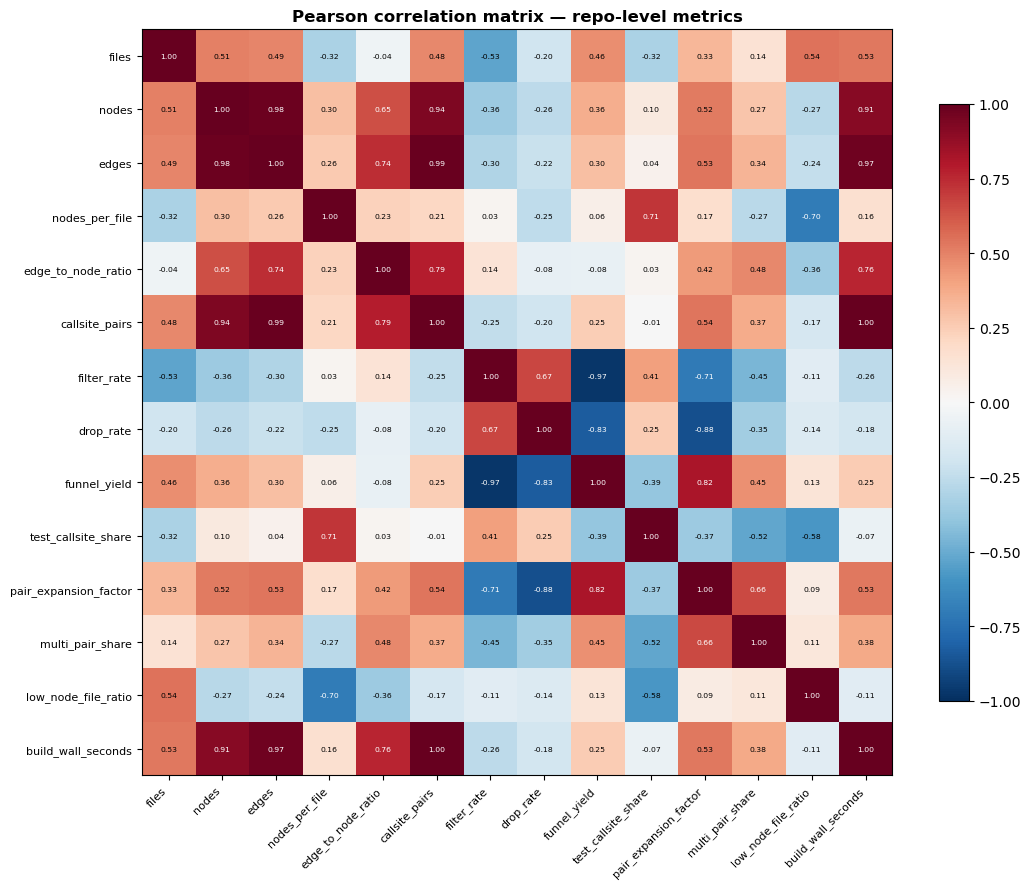

In [201]:
# ── 11a. Correlation matrix (repo-level) ──────────────────────────────────────
corr_cols = [
    "files", "nodes", "edges",
    "nodes_per_file", "edge_to_node_ratio",
    "callsite_pairs", "filter_rate", "drop_rate", "funnel_yield",
    "test_callsite_share", "pair_expansion_factor", "multi_pair_share",
    "low_node_file_ratio", "build_wall_seconds",
]

corr_matrix = repo_df[corr_cols].corr()

fig, ax = plt.subplots(figsize=(11, 9))
im = ax.imshow(corr_matrix, cmap="RdBu_r", vmin=-1, vmax=1, aspect="auto")
plt.colorbar(im, ax=ax, shrink=0.8)
ax.set_xticks(range(len(corr_cols))); ax.set_xticklabels(corr_cols, rotation=45, ha="right", fontsize=8)
ax.set_yticks(range(len(corr_cols))); ax.set_yticklabels(corr_cols, fontsize=8)

for i in range(len(corr_cols)):
    for j in range(len(corr_cols)):
        val = corr_matrix.iloc[i, j]
        ax.text(j, i, f"{val:.2f}", ha="center", va="center",
                fontsize=5.5, color="white" if abs(val) > 0.6 else "black")

ax.set_title("Pearson correlation matrix — repo-level metrics", fontweight="bold")
plt.tight_layout()
plt.show()

In [202]:
# ── 11b. Top correlations with build_wall_seconds ─────────────────────────────
build_corr = corr_matrix["build_wall_seconds"].drop("build_wall_seconds").sort_values(key=abs, ascending=False)
print("Correlations with build_wall_seconds:\n")
print(build_corr.round(4).to_string())

Correlations with build_wall_seconds:

callsite_pairs           0.9951
edges                    0.9716
nodes                    0.9124
edge_to_node_ratio       0.7619
pair_expansion_factor    0.5305
files                    0.5251
multi_pair_share         0.3762
filter_rate             -0.2600
funnel_yield             0.2542
drop_rate               -0.1806
nodes_per_file           0.1572
low_node_file_ratio     -0.1097
test_callsite_share     -0.0650


---
## 12  Anomaly / flag summary

In [203]:
# ── 12a. inflation_warning and warnings from structural_density ────────────────
inflation_flags = []
for repo, r in reports.items():
    t = r["summary"]["totals"]
    sd = t["structural_density"]
    inflation_flags.append({
        "repo": repo,
        "inflation_warning": sd.get("inflation_warning", False),
        "extra_warnings":    sd.get("warnings", []),
        "zero_node_files":   sd.get("zero_node_files_observed", 0),
        "low_node_files":    sd.get("low_node_files_leq_1", 0),
    })

inf_df = pd.DataFrame(inflation_flags).set_index("repo")
inf_df

,inflation_warning,extra_warnings,zero_node_files,low_node_files
repo,,,,
airbyte,False,[],0,734
axios,False,[],0,95
commons-lang,False,[],0,26
fastapi,False,[],0,211
guava,False,[],0,146
nest,False,[],0,534
pydantic,False,[],0,36
sympy,False,[],0,218
vscode,False,[],0,1508


In [204]:
# ── 12b. Statistical anomalies (z-score > 2) across key metrics ───────────────
check_cols = ["funnel_yield", "drop_rate", "filter_rate",
               "nodes_per_file", "edge_to_node_ratio",
               "low_node_file_ratio", "build_wall_seconds"]

z_df = repo_df[check_cols].copy()
z_scores = (z_df - z_df.mean()) / z_df.std()

anomalies = (z_scores.abs() > 2)
anomaly_report = []
for repo in anomalies.index:
    for col in anomalies.columns:
        if anomalies.loc[repo, col]:
            anomaly_report.append({
                "repo": repo, "metric": col,
                "value": round(repo_df.loc[repo, col], 4),
                "z_score": round(z_scores.loc[repo, col], 2)
            })

if anomaly_report:
    print("⚠️  Statistical outliers (|z| > 2):")
    display(pd.DataFrame(anomaly_report).sort_values("z_score", key=abs, ascending=False))
else:
    print("✅  No statistical outliers detected at |z| > 2.")

⚠️  Statistical outliers (|z| > 2):


,repo,metric,value,z_score
1,fastapi,drop_rate,0.4188,2.8300
3,vscode,build_wall_seconds,665.1299,2.7700
0,fastapi,funnel_yield,0.3100,-2.3400
4,webpack,low_node_file_ratio,0.8373,2.2900
2,vscode,edge_to_node_ratio,1.5863,2.1300


In [205]:
# ── 12c. Repos with non-zero persisted_dropped ────────────────────────────────
drop_issues = repo_df[repo_df["persisted_dropped"] > 0][["persisted_dropped", "drop_rate"]]\
    .sort_values("persisted_dropped", ascending=False)

if not drop_issues.empty:
    print("Repos with persisted_dropped > 0:")
    display(drop_issues.round(5))
else:
    print("✅  No persisted drops in any repo.")

Repos with persisted_dropped > 0:


,persisted_dropped,drop_rate
repo,,
vscode,3757,0.0259
guava,529,0.0149
fastapi,516,0.4188
airbyte,289,0.0196
sympy,210,0.0044
pydantic,142,0.0588
commons-lang,111,0.0202
webpack,77,0.0240
nest,59,0.0293


In [206]:
# ── 12d. Full anomaly / health dashboard ──────────────────────────────────────
health = repo_df[[
    "funnel_yield", "drop_rate", "filter_rate",
    "pair_expansion_factor", "low_node_file_ratio",
    "fpp_total_rate", "build_wall_seconds"
]].copy().round(4)

# Flag funnel_yield < 0.9 or drop_rate > 0.05 as noteworthy
health["⚠ low_yield"]    = health["funnel_yield"] < 0.90
health["⚠ high_drop"]    = health["drop_rate"]    > 0.05
health["⚠ high_filter"]  = health["filter_rate"]  > 0.15
health["⚠ sparse_files"] = health["low_node_file_ratio"] > 0.30

health.sort_values("funnel_yield", ascending=True)

,funnel_yield,drop_rate,filter_rate,pair_expansion_factor,low_node_file_ratio,fpp_total_rate,build_wall_seconds,⚠ low_yield,⚠ high_drop,⚠ high_filter,⚠ sparse_files
repo,,,,,,,,,,,
fastapi,0.3100,0.4188,0.4667,0.5812,0.1639,0.4667,11.3878,True,True,True,False
sympy,0.6483,0.0044,0.3488,0.9956,0.1371,0.3488,142.2320,True,False,True,False
pydantic,0.6966,0.0588,0.2599,0.9412,0.0885,0.2599,18.0347,True,True,True,False
axios,0.6970,0.0242,0.2857,1.0000,0.5491,0.2857,3.1120,True,False,True,True
nest,0.8296,0.0293,0.1453,1.0955,0.3126,0.1453,13.8438,True,False,False,True
vscode,0.9102,0.0259,0.0657,1.2177,0.2229,0.0657,665.1299,False,False,False,False
airbyte,0.9242,0.0196,0.0573,0.9812,0.2232,0.0573,63.1584,False,False,False,False
webpack,0.9308,0.0240,0.0463,0.9928,0.8373,0.0463,45.3109,False,False,False,True
commons-lang,0.9445,0.0202,0.0360,1.0421,0.0487,0.0360,18.7037,False,False,False,False
